# Task 3 — Evaluation on Mixed QCD + Emerging Jets Samples

Notebook di valutazione finale.

Cosa fa:

1. carica automaticamente gli score salvati dai vari modelli;
2. confronta QCD background vs Emerging Jets;
3. calcola ROC/AUC;
4. calcola signal efficiency a mistag rate fissato;
5. controlla train-vs-test-background;
6. confronta con baseline supervisionate;
7. produce interpretabilità leggera:
   - feature importanti da logistic regression;
   - PCA degli spazi latenti;
   - sensitivity trend usando proxy di displacement se LLP mass/ctau non sono disponibili.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)

OUTPUT_DIR = Path("outputs_task3")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)

## 1. Trova e carica gli score dei modelli

In [2]:
MODEL_REGISTRY = [
    {
        "model": "Stable RealNVP Flow",
        "path": Path("outputs_flow_stable/stable_realnvp_flow_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "NLL = -log p(x)",
    },
    {
        "model": "RealNVP Flow",
        "path": Path("outputs_flow/realnvp_flow_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "NLL = -log p(x)",
    },
    {
        "model": "Diffusion v2 z-all",
        "path": Path("outputs_diffusion_v2/tabular_diffusion_v2_scores.npz"),
        "bg_key": "scores_bg_z_all",
        "sig_key": "scores_sig_z_all",
        "train_key": "scores_train_z_all",
        "score_name": "z-normalized denoising score",
    },
    {
        "model": "Diffusion v2 z-mid",
        "path": Path("outputs_diffusion_v2/tabular_diffusion_v2_scores.npz"),
        "bg_key": "scores_bg_z_mid",
        "sig_key": "scores_sig_z_mid",
        "train_key": None,
        "score_name": "z-normalized mid timestep denoising score",
    },
    {
        "model": "Diffusion",
        "path": Path("outputs_diffusion/tabular_diffusion_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "denoising score",
    },
    {
        "model": "Transformer Set AE total",
        "path": Path("outputs_transformer_set/transformer_set_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "reconstruction score",
    },
    {
        "model": "Transformer Set AE track",
        "path": Path("outputs_transformer_set/transformer_set_scores.npz"),
        "bg_key": "scores_bg_tracks",
        "sig_key": "scores_sig_tracks",
        "train_key": "scores_train_tracks",
        "score_name": "track reconstruction score",
    },
    {
        "model": "Transformer Deep SVDD",
        "path": Path("outputs_transformer_svdd/transformer_deep_svdd_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "||z-c||²",
    },
    {
        "model": "GNN Constituents AE total",
        "path": Path("outputs_gnn/gnn_constituent_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "graph reconstruction score",
    },
    {
        "model": "GNN Constituents AE track",
        "path": Path("outputs_gnn/gnn_constituent_scores.npz"),
        "bg_key": "scores_bg_tracks",
        "sig_key": "scores_sig_tracks",
        "train_key": "scores_train_tracks",
        "score_name": "track reconstruction score",
    },
    {
        "model": "Aggregate AE",
        "path": Path("outputs_clean/clean_ae_vae_scores.npz"),
        "bg_key": "ae_scores_bg",
        "sig_key": "ae_scores_sig",
        "train_key": "ae_scores_train",
        "score_name": "aggregate AE reconstruction score",
    },
    {
        "model": "Aggregate VAE reco",
        "path": Path("outputs_clean/clean_ae_vae_scores.npz"),
        "bg_key": "vae_scores_bg_reco",
        "sig_key": "vae_scores_sig_reco",
        "train_key": "vae_scores_train_reco",
        "score_name": "aggregate VAE reconstruction score",
    },
    {
        "model": "Aggregate VAE total",
        "path": Path("outputs_clean/clean_ae_vae_scores.npz"),
        "bg_key": "vae_scores_bg_total",
        "sig_key": "vae_scores_sig_total",
        "train_key": "vae_scores_train_total",
        "score_name": "aggregate VAE total score",
    },
]

def sanitize_scores(x):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    finite = np.isfinite(x)
    if not finite.all():
        print("Removed non-finite scores:", np.sum(~finite))
        x = x[finite]
    return x

available = []

for item in MODEL_REGISTRY:
    if not item["path"].exists():
        print("Missing file:", item["model"], item["path"])
        continue

    data = np.load(item["path"], allow_pickle=True)
    keys = list(data.keys())

    if item["bg_key"] not in keys or item["sig_key"] not in keys:
        print("Missing keys:", item["model"], "available:", keys)
        continue

    print("Available:", item["model"])
    available.append(item)

print("\nAvailable model scores:", len(available))

Available: Stable RealNVP Flow
Available: RealNVP Flow
Available: Diffusion v2 z-all
Available: Diffusion v2 z-mid
Available: Diffusion
Available: Transformer Set AE total
Available: Transformer Set AE track
Available: Transformer Deep SVDD
Missing file: GNN Constituents AE total outputs_gnn\gnn_constituent_scores.npz
Missing file: GNN Constituents AE track outputs_gnn\gnn_constituent_scores.npz
Available: Aggregate AE
Available: Aggregate VAE reco
Available: Aggregate VAE total

Available model scores: 11


## 2. Metriche comuni

In [3]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def metrics_for_scores(bg, sig, train=None):
    bg = sanitize_scores(bg)
    sig = sanitize_scores(sig)

    bg_o, sig_o, best_auc, inverted, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    mistag_targets = [0.30, 0.10, 0.05, 0.01, 0.001]
    effs = {}

    for m in mistag_targets:
        threshold = np.quantile(bg_o, 1.0 - m)
        effs[f"eff_at_{m:g}_mistag"] = float(np.mean(sig_o >= threshold))
        effs[f"actual_mistag_at_{m:g}"] = float(np.mean(bg_o >= threshold))
        effs[f"threshold_at_{m:g}"] = float(threshold)

    train_bg_auc = None
    train_bg_auc_inv = None
    train_bg_best_auc = None

    if train is not None:
        train = sanitize_scores(train)
        train_o = -train if inverted else train

        y_tb = np.concatenate([np.zeros_like(train_o), np.ones_like(bg_o)])
        s_tb = np.concatenate([train_o, bg_o])

        train_bg_auc = roc_auc_score(y_tb, s_tb)
        train_bg_auc_inv = roc_auc_score(y_tb, -s_tb)
        train_bg_best_auc = max(train_bg_auc, train_bg_auc_inv)

    return {
        "auc": float(auc),
        "auc_inverted": float(auc_inv),
        "best_auc": float(best_auc),
        "score_inverted": bool(inverted),
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "train_bg_auc": train_bg_auc,
        "train_bg_auc_inverted": train_bg_auc_inv,
        "train_bg_best_auc": train_bg_best_auc,
        **effs,
    }

## 3. Costruisci tabella comparativa

In [4]:
rows = []
loaded = {}

for item in available:
    data = np.load(item["path"], allow_pickle=True)

    bg = sanitize_scores(data[item["bg_key"]])
    sig = sanitize_scores(data[item["sig_key"]])

    train = None
    if item.get("train_key") is not None and item["train_key"] in data:
        train = sanitize_scores(data[item["train_key"]])

    met = metrics_for_scores(bg, sig, train=train)

    row = {
        "model": item["model"],
        "score_name": item["score_name"],
        "path": str(item["path"]),
        "bg_key": item["bg_key"],
        "sig_key": item["sig_key"],
        "n_bg": len(bg),
        "n_sig": len(sig),
        "auc": met["auc"],
        "auc_inverted": met["auc_inverted"],
        "best_auc": met["best_auc"],
        "score_inverted": met["score_inverted"],
        "train_bg_best_auc": met["train_bg_best_auc"],
        "eff_at_0.3_mistag": met["eff_at_0.3_mistag"],
        "eff_at_0.1_mistag": met["eff_at_0.1_mistag"],
        "eff_at_0.05_mistag": met["eff_at_0.05_mistag"],
        "eff_at_0.01_mistag": met["eff_at_0.01_mistag"],
        "eff_at_0.001_mistag": met["eff_at_0.001_mistag"],
    }

    rows.append(row)

    loaded[item["model"]] = {
        "entry": item,
        "bg_scores": bg,
        "sig_scores": sig,
        "train_scores": train,
        "metrics": met,
    }

df_results = pd.DataFrame(rows).sort_values("best_auc", ascending=False).reset_index(drop=True)
display(df_results)

df_results.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)
print("Saved:", OUTPUT_DIR / "model_comparison_metrics.csv")

,model,score_name,path,bg_key,sig_key,n_bg,n_sig,auc,auc_inverted,best_auc,score_inverted,train_bg_best_auc,eff_at_0.3_mistag,eff_at_0.1_mistag,eff_at_0.05_mistag,eff_at_0.01_mistag,eff_at_0.001_mistag
0,Transformer Deep SVDD,||z-c||²,outputs_transformer_svdd\transformer_deep_svdd...,scores_bg,scores_sig,100000,59643,0.889926,0.110074,0.889926,False,0.500055,0.884664,0.690006,0.559278,0.292390,0.076924
1,RealNVP Flow,NLL = -log p(x),outputs_flow\realnvp_flow_scores.npz,scores_bg,scores_sig,100000,59644,0.876477,0.123523,0.876477,False,0.511928,0.876165,0.637130,0.464808,0.168265,0.025200
2,Diffusion v2 z-all,z-normalized denoising score,outputs_diffusion_v2\tabular_diffusion_v2_scor...,scores_bg_z_all,scores_sig_z_all,100000,59643,0.876389,0.123611,0.876389,False,NaN,0.868803,0.642640,0.498097,0.236977,0.056738
3,Stable RealNVP Flow,NLL = -log p(x),outputs_flow_stable\stable_realnvp_flow_scores...,scores_bg,scores_sig,100000,59643,0.871314,0.128686,0.871314,False,0.502658,0.875207,0.615395,0.439113,0.159013,0.010026
4,Diffusion v2 z-mid,z-normalized mid timestep denoising score,outputs_diffusion_v2\tabular_diffusion_v2_scor...,scores_bg_z_mid,scores_sig_z_mid,100000,59643,0.849824,0.150176,0.849824,False,NaN,0.822226,0.589759,0.457925,0.238066,0.067166
5,Aggregate VAE total,aggregate VAE total score,outputs_clean\clean_ae_vae_scores.npz,vae_scores_bg_total,vae_scores_sig_total,100000,59644,0.847705,0.152295,0.847705,False,0.507620,0.823989,0.566243,0.420813,0.192593,0.057424
6,Aggregate AE,aggregate AE reconstruction score,outputs_clean\clean_ae_vae_scores.npz,ae_scores_bg,ae_scores_sig,100000,59644,0.840991,0.159009,0.840991,False,0.508422,0.812957,0.559470,0.420830,0.180286,0.048957
7,Aggregate VAE reco,aggregate VAE reconstruction score,outputs_clean\clean_ae_vae_scores.npz,vae_scores_bg_reco,vae_scores_sig_reco,100000,59644,0.838279,0.161721,0.838279,False,0.508023,0.808749,0.553383,0.414157,0.188887,0.058531
8,Transformer Set AE total,reconstruction score,outputs_transformer_set\transformer_set_scores...,scores_bg,scores_sig,100000,59643,0.801245,0.198755,0.801245,False,0.503636,0.753919,0.422464,0.294402,0.126419,0.004208
9,Diffusion,denoising score,outputs_diffusion\tabular_diffusion_scores.npz,scores_bg,scores_sig,100000,59643,0.760283,0.239717,0.760283,False,0.502115,0.682813,0.418306,0.297151,0.125010,0.006371


Saved: outputs_task3\model_comparison_metrics.csv


## 4. ROC curves sovrapposte

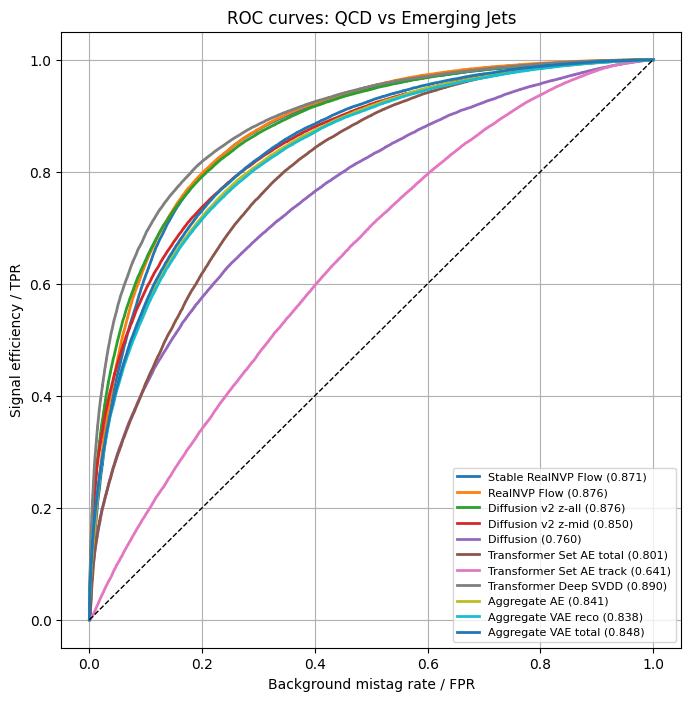

In [5]:
plt.figure(figsize=(8, 8))

for name, obj in loaded.items():
    met = obj["metrics"]
    plt.plot(met["fpr"], met["tpr"], linewidth=2, label=f"{name} ({met['best_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
plt.xlabel("Background mistag rate / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curves: QCD vs Emerging Jets")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

## 5. Signal efficiency vs mistag rate

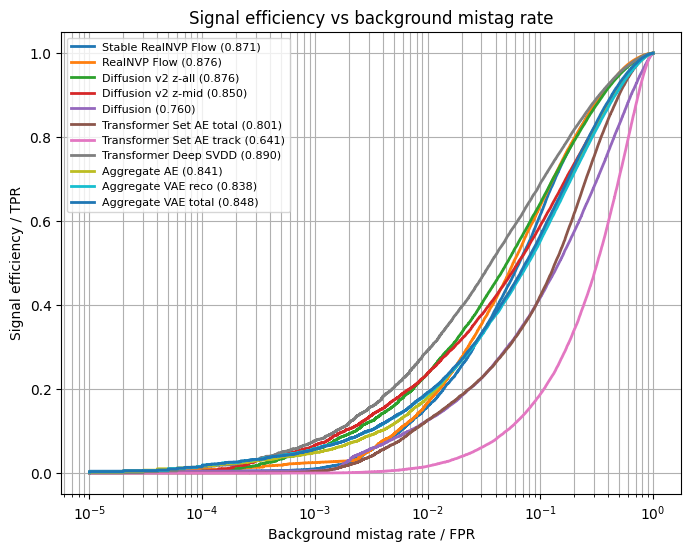

,model,best_auc,train_bg_best_auc,eff_at_0.3_mistag,eff_at_0.1_mistag,eff_at_0.05_mistag,eff_at_0.01_mistag,eff_at_0.001_mistag
0,Transformer Deep SVDD,0.889926,0.500055,0.884664,0.690006,0.559278,0.292390,0.076924
1,RealNVP Flow,0.876477,0.511928,0.876165,0.637130,0.464808,0.168265,0.025200
2,Diffusion v2 z-all,0.876389,NaN,0.868803,0.642640,0.498097,0.236977,0.056738
3,Stable RealNVP Flow,0.871314,0.502658,0.875207,0.615395,0.439113,0.159013,0.010026
4,Diffusion v2 z-mid,0.849824,NaN,0.822226,0.589759,0.457925,0.238066,0.067166
5,Aggregate VAE total,0.847705,0.507620,0.823989,0.566243,0.420813,0.192593,0.057424
6,Aggregate AE,0.840991,0.508422,0.812957,0.559470,0.420830,0.180286,0.048957
7,Aggregate VAE reco,0.838279,0.508023,0.808749,0.553383,0.414157,0.188887,0.058531
8,Transformer Set AE total,0.801245,0.503636,0.753919,0.422464,0.294402,0.126419,0.004208
9,Diffusion,0.760283,0.502115,0.682813,0.418306,0.297151,0.125010,0.006371


In [6]:
plt.figure(figsize=(8, 6))

for name, obj in loaded.items():
    met = obj["metrics"]
    fpr = met["fpr"]
    tpr = met["tpr"]

    m = fpr > 0
    plt.plot(fpr[m], tpr[m], linewidth=2, label=f"{name} ({met['best_auc']:.3f})")

plt.xscale("log")
plt.xlabel("Background mistag rate / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("Signal efficiency vs background mistag rate")
plt.grid(True, which="both")
plt.legend(fontsize=8)
plt.show()

cols = [
    "model",
    "best_auc",
    "train_bg_best_auc",
    "eff_at_0.3_mistag",
    "eff_at_0.1_mistag",
    "eff_at_0.05_mistag",
    "eff_at_0.01_mistag",
    "eff_at_0.001_mistag",
]
display(df_results[cols])

## 6. Distribuzioni score dei migliori modelli

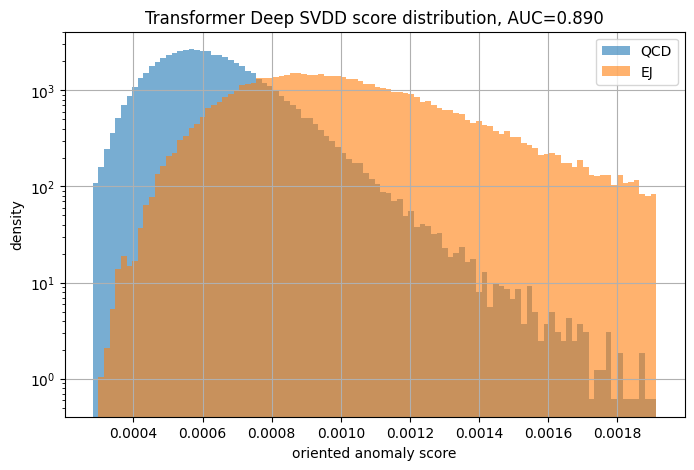

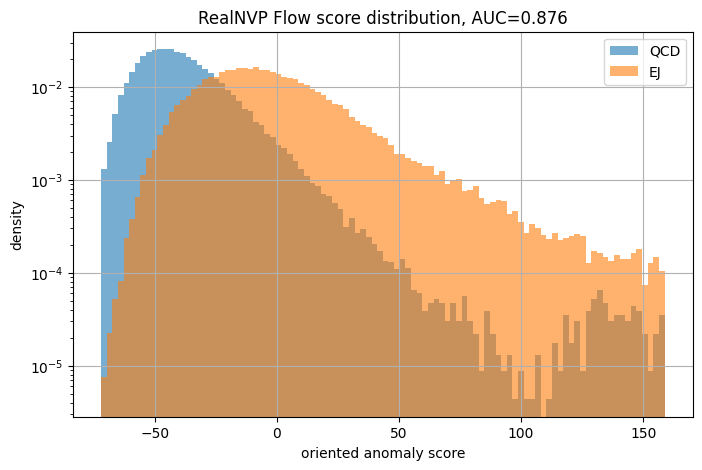

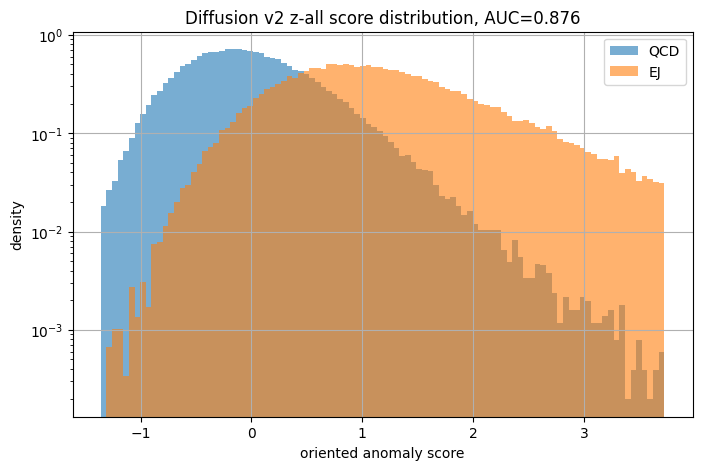

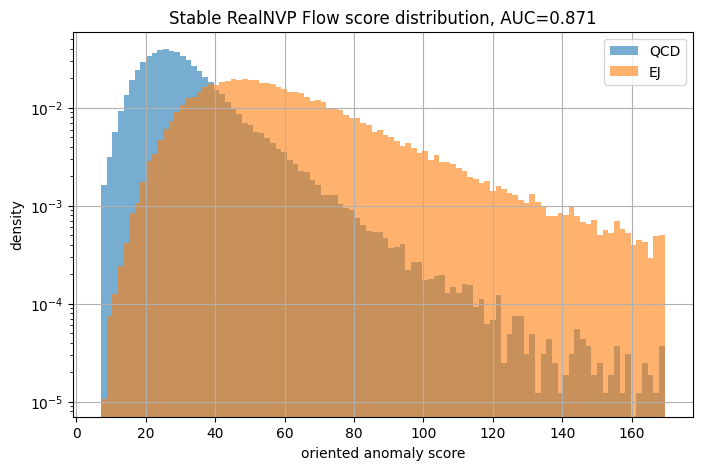

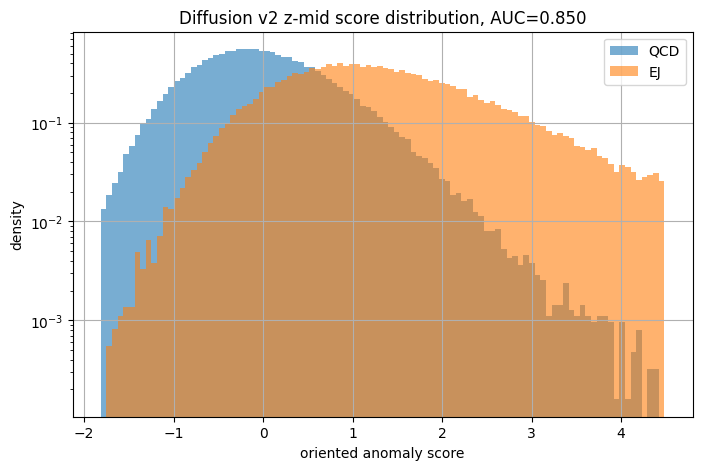

In [7]:
def plot_score_distribution(model_name, zoom_percentile=99):
    obj = loaded[model_name]
    met = obj["metrics"]

    bg = met["bg_oriented"]
    sig = met["sig_oriented"]

    all_scores = np.concatenate([bg, sig])
    lo = np.percentile(all_scores, 0.1)
    hi = np.percentile(all_scores, zoom_percentile)

    plt.figure(figsize=(8, 5))
    plt.hist(bg, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD")
    plt.hist(sig, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ")
    plt.yscale("log")
    plt.xlabel("oriented anomaly score")
    plt.ylabel("density")
    plt.title(f"{model_name} score distribution, AUC={met['best_auc']:.3f}")
    plt.legend()
    plt.grid(True)
    plt.show()

for model_name in df_results["model"].head(min(5, len(df_results))).tolist():
    plot_score_distribution(model_name)

## 7. Background compatibility check

,model,best_auc,train_bg_best_auc
0,Transformer Deep SVDD,0.889926,0.500055
9,Diffusion,0.760283,0.502115
10,Transformer Set AE track,0.640838,0.502604
3,Stable RealNVP Flow,0.871314,0.502658
8,Transformer Set AE total,0.801245,0.503636
5,Aggregate VAE total,0.847705,0.507620
7,Aggregate VAE reco,0.838279,0.508023
6,Aggregate AE,0.840991,0.508422
1,RealNVP Flow,0.876477,0.511928
2,Diffusion v2 z-all,0.876389,NaN


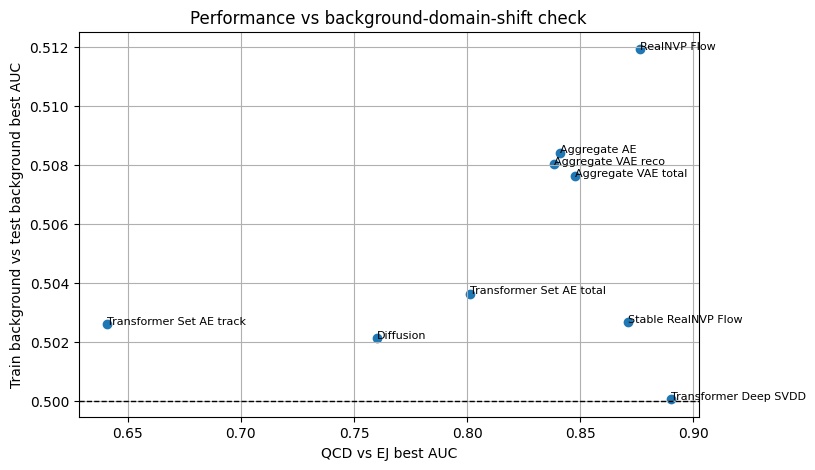

In [8]:
df_bgcheck = df_results[["model", "best_auc", "train_bg_best_auc"]].copy()
display(df_bgcheck.sort_values("train_bg_best_auc", ascending=True, na_position="last"))

valid = df_results.dropna(subset=["train_bg_best_auc"])

plt.figure(figsize=(8, 5))
plt.scatter(valid["best_auc"], valid["train_bg_best_auc"])

for _, row in valid.iterrows():
    plt.text(row["best_auc"], row["train_bg_best_auc"], row["model"], fontsize=8)

plt.axhline(0.5, linestyle="--", color="black", linewidth=1)
plt.xlabel("QCD vs EJ best AUC")
plt.ylabel("Train background vs test background best AUC")
plt.title("Performance vs background-domain-shift check")
plt.grid(True)
plt.show()

## 8. Baseline supervisionata su feature aggregate

In [9]:
def find_processed_dataset():
    candidates = [
        ("processed_flow", Path("processed_flow"), {
            "val": "processed_flow_jet_track_val.npz",
            "test_background": "processed_flow_jet_track_test_background.npz",
            "test_signal": "processed_flow_jet_track_test_signal.npz",
        }),
        ("processed_clean", Path("processed_clean"), {
            "val": "processed_clean_jet_track_val.npz",
            "test_background": "processed_clean_jet_track_test_background.npz",
            "test_signal": "processed_clean_jet_track_test_signal.npz",
        }),
        ("processed", Path("processed"), {
            "val": "processed_jet_track_val.npz",
            "test_background": "processed_jet_track_test_background.npz",
            "test_signal": "processed_jet_track_test_signal.npz",
        }),
    ]

    for name, base, files in candidates:
        paths = {k: base / v for k, v in files.items()}
        if all(p.exists() for p in paths.values()):
            return name, paths

    return None, None


def aggregate_track_features(X_tracks, mask):
    features = []
    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def build_aggregate_matrix(X_jets, X_tracks, mask):
    return np.concatenate([X_jets.astype(np.float32), aggregate_track_features(X_tracks, mask)], axis=1)


dataset_name, dataset_files = find_processed_dataset()
supervised_results = {}

if dataset_files is None:
    print("No processed dataset found. Skipping supervised baseline.")
else:
    print("Using processed dataset:", dataset_name)

    data_bg = np.load(dataset_files["test_background"], allow_pickle=True)
    data_sig = np.load(dataset_files["test_signal"], allow_pickle=True)

    X_jets_bg = data_bg["X_jets"].astype(np.float32)
    X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
    mask_bg = data_bg["track_mask"].astype(bool)

    X_jets_sig = data_sig["X_jets"].astype(np.float32)
    X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
    mask_sig = data_sig["track_mask"].astype(bool)

    if "meta_isDisplaced" in data_sig:
        sig_filter = data_sig["meta_isDisplaced"] == 1
        X_jets_sig = X_jets_sig[sig_filter]
        X_tracks_sig = X_tracks_sig[sig_filter]
        mask_sig = mask_sig[sig_filter]

    bg_filter = mask_bg.sum(axis=1) > 0
    sig_filter = mask_sig.sum(axis=1) > 0

    X_jets_bg = X_jets_bg[bg_filter]
    X_tracks_bg = X_tracks_bg[bg_filter]
    mask_bg = mask_bg[bg_filter]

    X_jets_sig = X_jets_sig[sig_filter]
    X_tracks_sig = X_tracks_sig[sig_filter]
    mask_sig = mask_sig[sig_filter]

    A_bg = build_aggregate_matrix(X_jets_bg, X_tracks_bg, mask_bg)
    A_sig = build_aggregate_matrix(X_jets_sig, X_tracks_sig, mask_sig)

    X = np.concatenate([A_bg, A_sig], axis=0)
    y = np.concatenate([
        np.zeros(A_bg.shape[0], dtype=np.int64),
        np.ones(A_sig.shape[0], dtype=np.int64),
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=3000)

    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf.fit(X_train_s, y_train)
    proba = clf.predict_proba(X_test_s)[:, 1]

    auc_sup = roc_auc_score(y_test, proba)
    fpr_sup, tpr_sup, _ = roc_curve(y_test, proba)

    supervised_results["Aggregate logistic regression"] = {
        "auc": auc_sup,
        "fpr": fpr_sup,
        "tpr": tpr_sup,
        "clf": clf,
        "scaler": scaler,
        "feature_dim": X.shape[1],
    }

    print("Supervised aggregate logistic regression AUC:", auc_sup)

Using processed dataset: processed_flow
Supervised aggregate logistic regression AUC: 0.9946137129976342


## 9. Baseline supervisionata su latent embeddings

In [10]:
latent_candidates = [
    {
        "name": "Transformer Set AE latent",
        "path": Path("outputs_transformer_set/transformer_set_scores.npz"),
        "bg_key": "Z_bg",
        "sig_key": "Z_sig",
    },
    {
        "name": "Transformer Deep SVDD latent",
        "path": Path("outputs_transformer_svdd/transformer_deep_svdd_scores.npz"),
        "bg_key": "Z_bg",
        "sig_key": "Z_sig",
    },
    {
        "name": "GNN latent",
        "path": Path("outputs_gnn/gnn_constituent_scores.npz"),
        "bg_key": "Z_bg",
        "sig_key": "Z_sig",
    },
]

latent_results = {}

for item in latent_candidates:
    if not item["path"].exists():
        print("Missing latent file:", item["name"], item["path"])
        continue

    data = np.load(item["path"], allow_pickle=True)

    if item["bg_key"] not in data or item["sig_key"] not in data:
        print("Missing latent keys:", item["name"])
        continue

    Z_bg = np.asarray(data[item["bg_key"]], dtype=np.float32)
    Z_sig = np.asarray(data[item["sig_key"]], dtype=np.float32)

    X = np.concatenate([Z_bg, Z_sig], axis=0)
    y = np.concatenate([
        np.zeros(Z_bg.shape[0], dtype=np.int64),
        np.ones(Z_sig.shape[0], dtype=np.int64),
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=3000)

    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf.fit(X_train_s, y_train)
    proba = clf.predict_proba(X_test_s)[:, 1]

    auc_lat = roc_auc_score(y_test, proba)
    fpr_lat, tpr_lat, _ = roc_curve(y_test, proba)

    latent_results[item["name"]] = {
        "auc": auc_lat,
        "fpr": fpr_lat,
        "tpr": tpr_lat,
        "Z_bg": Z_bg,
        "Z_sig": Z_sig,
    }

    print(item["name"], "AUC:", auc_lat)

Transformer Set AE latent AUC: 0.9923529648465882
Transformer Deep SVDD latent AUC: 0.9859243204977738
Missing latent file: GNN latent outputs_gnn\gnn_constituent_scores.npz


## 10. ROC: unsupervised vs supervised

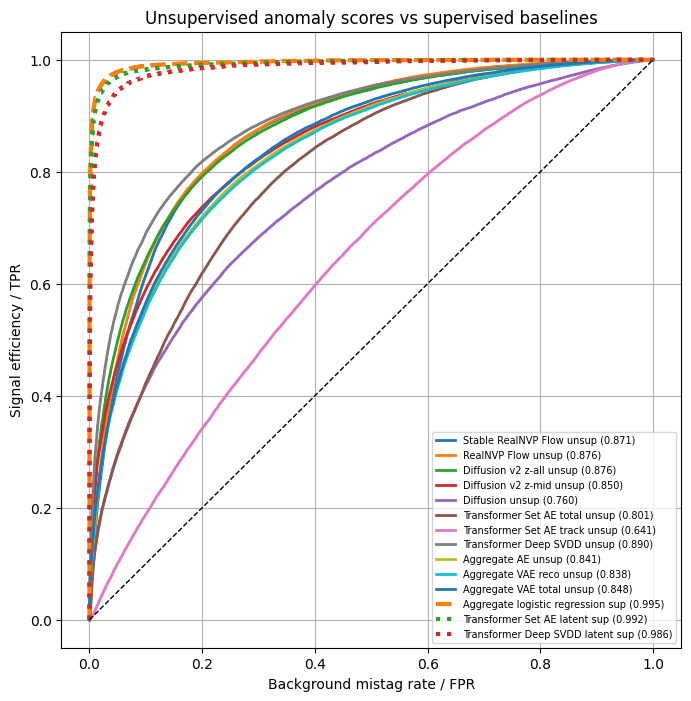

In [11]:
plt.figure(figsize=(8, 8))

for name, obj in loaded.items():
    met = obj["metrics"]
    plt.plot(met["fpr"], met["tpr"], linewidth=2, label=f"{name} unsup ({met['best_auc']:.3f})")

for name, obj in supervised_results.items():
    plt.plot(obj["fpr"], obj["tpr"], linestyle="--", linewidth=3, label=f"{name} sup ({obj['auc']:.3f})")

for name, obj in latent_results.items():
    plt.plot(obj["fpr"], obj["tpr"], linestyle=":", linewidth=3, label=f"{name} sup ({obj['auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
plt.xlabel("Background mistag rate / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("Unsupervised anomaly scores vs supervised baselines")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()

## 11. Interpretabilità: top feature aggregate

,feature,coef,abs_coef
12,ECF1_clusterSoftDrop,6.317301,6.317301
0,pt,-6.171293,6.171293
6,D2_clusterSoftDrop,-5.048862,5.048862
13,ECF2_clusterSoftDrop,-3.798409,3.798409
40,radiusOfFirstHit_mean,3.089101,3.089101
10,Tau21_clusterSoftDrop,2.843060,2.843060
2,mass,2.730199,2.730199
14,n_valid_tracks,-2.594203,2.594203
5,C2_clusterSoftDrop,2.190322,2.190322
8,Tau2_clusterSoftDrop,1.937743,1.937743


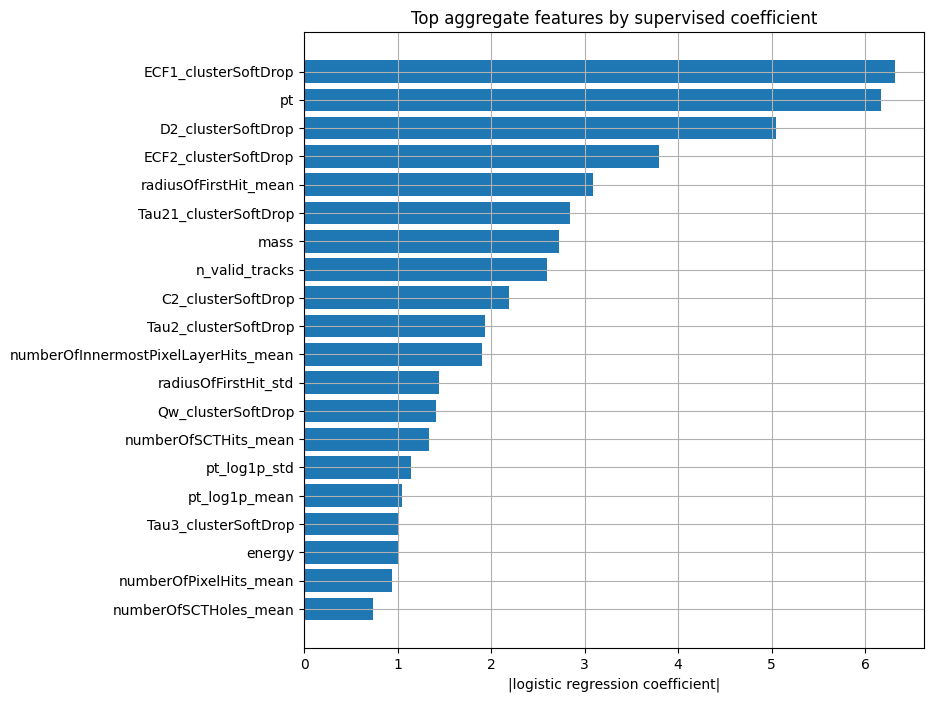

Saved: outputs_task3\supervised_feature_coefficients.csv


In [12]:
if dataset_files is None or "Aggregate logistic regression" not in supervised_results:
    print("Skipping feature interpretability.")
else:
    data_bg = np.load(dataset_files["test_background"], allow_pickle=True)
    jet_feature_names = list(data_bg["jet_feature_names"])
    track_feature_names = list(data_bg["track_feature_names"])

    feature_names = []
    feature_names.extend(jet_feature_names)
    feature_names.append("n_valid_tracks")
    for feat in track_feature_names:
        feature_names.extend([
            f"{feat}_mean",
            f"{feat}_std",
            f"{feat}_median",
            f"{feat}_q90",
            f"{feat}_max",
        ])

    clf = supervised_results["Aggregate logistic regression"]["clf"]
    coefs = clf.coef_[0]

    df_coef = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs),
    }).sort_values("abs_coef", ascending=False)

    display(df_coef.head(30))

    plt.figure(figsize=(8, 8))
    top = df_coef.head(20).iloc[::-1]
    plt.barh(top["feature"], top["abs_coef"])
    plt.xlabel("|logistic regression coefficient|")
    plt.title("Top aggregate features by supervised coefficient")
    plt.grid(True)
    plt.show()

    df_coef.to_csv(OUTPUT_DIR / "supervised_feature_coefficients.csv", index=False)
    print("Saved:", OUTPUT_DIR / "supervised_feature_coefficients.csv")

## 12. PCA latent space

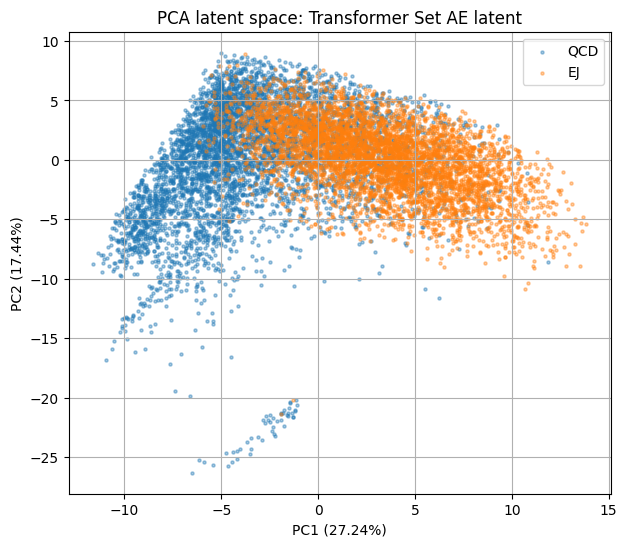

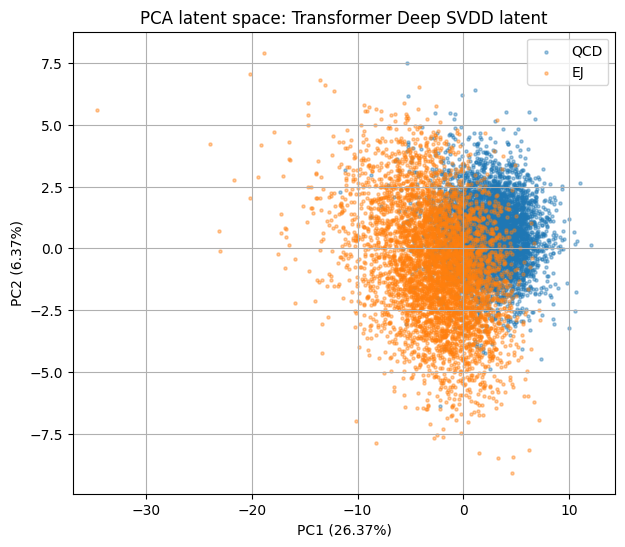

In [13]:
def pca_latent_plot(name, Z_bg, Z_sig, max_points=5000):
    rng = np.random.default_rng(42)

    n_bg = min(max_points, Z_bg.shape[0])
    n_sig = min(max_points, Z_sig.shape[0])

    idx_bg = rng.choice(Z_bg.shape[0], size=n_bg, replace=False)
    idx_sig = rng.choice(Z_sig.shape[0], size=n_sig, replace=False)

    X = np.concatenate([Z_bg[idx_bg], Z_sig[idx_sig]], axis=0)
    y = np.concatenate([
        np.zeros(n_bg, dtype=np.int64),
        np.ones(n_sig, dtype=np.int64),
    ])

    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(Xs)

    plt.figure(figsize=(7, 6))
    plt.scatter(X2[y == 0, 0], X2[y == 0, 1], s=5, alpha=0.4, label="QCD")
    plt.scatter(X2[y == 1, 0], X2[y == 1, 1], s=5, alpha=0.4, label="EJ")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.title(f"PCA latent space: {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

for name, obj in latent_results.items():
    pca_latent_plot(name, obj["Z_bg"], obj["Z_sig"])

## 13. Sensitivity trend con proxy di displacement

Best model: Transformer Deep SVDD
Threshold at 1% QCD mistag: 0.001164788221940397


,model,proxy,bin_low,bin_high,n_signal,eff_at_1pct_mistag
0,Transformer Deep SVDD,radiusOfFirstHit_median,-0.514983,-0.490291,14911,0.306619
1,Transformer Deep SVDD,radiusOfFirstHit_median,-0.490291,-0.142166,14910,0.271898
2,Transformer Deep SVDD,radiusOfFirstHit_median,-0.142166,0.091156,14911,0.268996
3,Transformer Deep SVDD,radiusOfFirstHit_median,0.091156,3.684197,14911,0.322044


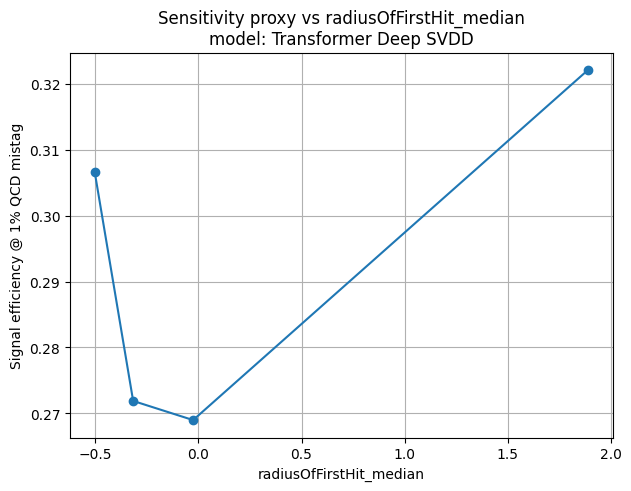

,model,proxy,bin_low,bin_high,n_signal,eff_at_1pct_mistag
0,Transformer Deep SVDD,abs_d0_median,0.009454,0.014489,14911,0.313057
1,Transformer Deep SVDD,abs_d0_median,0.014489,0.032898,14910,0.235681
2,Transformer Deep SVDD,abs_d0_median,0.032898,0.056564,14911,0.248944
3,Transformer Deep SVDD,abs_d0_median,0.056564,1.328758,14911,0.371873


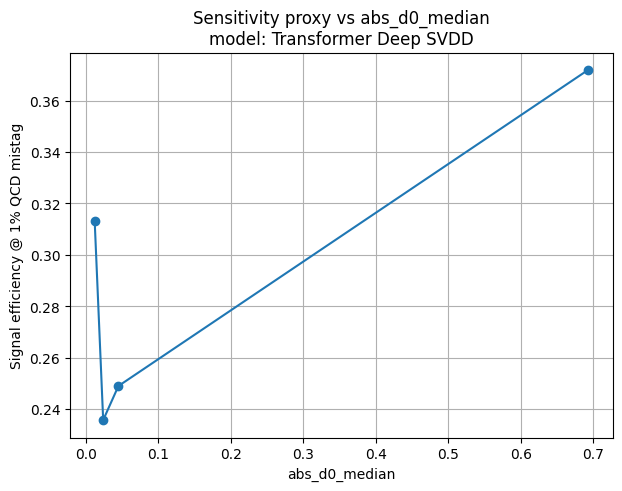

Saved: outputs_task3\sensitivity_proxy_results.csv


In [14]:
# Se mancano LLP mass/ctau, usiamo proxy track-level:
# - median radiusOfFirstHit
# - median |d0|
# Valutiamo signal efficiency a 1% QCD mistag in bin della proxy.

if dataset_files is None or len(df_results) == 0:
    print("Skipping sensitivity proxy.")
else:
    data_sig = np.load(dataset_files["test_signal"], allow_pickle=True)

    X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
    mask_sig_proxy = data_sig["track_mask"].astype(bool)

    if "meta_isDisplaced" in data_sig:
        sig_filter = data_sig["meta_isDisplaced"] == 1
        X_tracks_sig = X_tracks_sig[sig_filter]
        mask_sig_proxy = mask_sig_proxy[sig_filter]

    nonempty = mask_sig_proxy.sum(axis=1) > 0
    X_tracks_sig = X_tracks_sig[nonempty]
    mask_sig_proxy = mask_sig_proxy[nonempty]

    track_feature_names = list(data_sig["track_feature_names"])

    proxies = []

    if "radiusOfFirstHit" in track_feature_names:
        idx = track_feature_names.index("radiusOfFirstHit")
        vals = X_tracks_sig[:, :, idx]
        proxy = np.nanmedian(np.where(mask_sig_proxy, vals, np.nan), axis=1)
        proxy = np.nan_to_num(proxy, nan=0.0, posinf=0.0, neginf=0.0)
        proxies.append(("radiusOfFirstHit_median", proxy))

    if "d0" in track_feature_names:
        idx = track_feature_names.index("d0")
        vals = np.abs(X_tracks_sig[:, :, idx])
        proxy = np.nanmedian(np.where(mask_sig_proxy, vals, np.nan), axis=1)
        proxy = np.nan_to_num(proxy, nan=0.0, posinf=0.0, neginf=0.0)
        proxies.append(("abs_d0_median", proxy))

    if len(proxies) == 0:
        print("No displacement proxy available.")
    else:
        best_model = df_results.iloc[0]["model"]
        obj = loaded[best_model]
        bg_scores = obj["metrics"]["bg_oriented"]
        sig_scores = obj["metrics"]["sig_oriented"]

        threshold = np.quantile(bg_scores, 0.99)

        print("Best model:", best_model)
        print("Threshold at 1% QCD mistag:", threshold)

        all_proxy_rows = []

        for proxy_name, proxy_values in proxies:
            n = min(len(proxy_values), len(sig_scores))
            proxy_values = proxy_values[:n]
            sig_scores_use = sig_scores[:n]

            edges = np.unique(np.quantile(proxy_values, [0, 0.25, 0.50, 0.75, 1.0]))
            rows = []

            for i in range(len(edges) - 1):
                lo = edges[i]
                hi = edges[i + 1]

                if i == len(edges) - 2:
                    m = (proxy_values >= lo) & (proxy_values <= hi)
                else:
                    m = (proxy_values >= lo) & (proxy_values < hi)

                if m.sum() == 0:
                    continue

                eff = np.mean(sig_scores_use[m] >= threshold)

                rows.append({
                    "model": best_model,
                    "proxy": proxy_name,
                    "bin_low": lo,
                    "bin_high": hi,
                    "n_signal": int(m.sum()),
                    "eff_at_1pct_mistag": eff,
                })

            df_proxy = pd.DataFrame(rows)
            display(df_proxy)

            plt.figure(figsize=(7, 5))
            centers = 0.5 * (df_proxy["bin_low"] + df_proxy["bin_high"])
            plt.plot(centers, df_proxy["eff_at_1pct_mistag"], marker="o")
            plt.xlabel(proxy_name)
            plt.ylabel("Signal efficiency @ 1% QCD mistag")
            plt.title(f"Sensitivity proxy vs {proxy_name}\nmodel: {best_model}")
            plt.grid(True)
            plt.show()

            all_proxy_rows.append(df_proxy)

        if len(all_proxy_rows) > 0:
            df_proxy_all = pd.concat(all_proxy_rows, ignore_index=True)
            df_proxy_all.to_csv(OUTPUT_DIR / "sensitivity_proxy_results.csv", index=False)
            print("Saved:", OUTPUT_DIR / "sensitivity_proxy_results.csv")

## 14. Salvataggio sommario finale

In [16]:
summary = {
    "models_evaluated": df_results["model"].tolist(),
    "best_model_by_auc": df_results.iloc[0]["model"] if len(df_results) else None,
    "best_auc": float(df_results.iloc[0]["best_auc"]) if len(df_results) else None,
    "output_dir": str(OUTPUT_DIR),
}

with open(OUTPUT_DIR / "task3_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

with open(OUTPUT_DIR / "task3_summary.md", "w", encoding="utf-8") as f:
    f.write("# Task 3 Summary\n\n")
    f.write(f"Best model by AUC: **{summary['best_model_by_auc']}**\n\n")
    if summary["best_auc"] is not None:
        f.write(f"Best AUC: **{summary['best_auc']:.4f}**\n\n")
    f.write("## Model comparison\n\n")
    f.write(df_results.to_markdown(index=False))

print("Saved:")
print(OUTPUT_DIR / "model_comparison_metrics.csv")
print(OUTPUT_DIR / "task3_summary.json")
print(OUTPUT_DIR / "task3_summary.md")

Saved:
outputs_task3\model_comparison_metrics.csv
outputs_task3\task3_summary.json
outputs_task3\task3_summary.md


## Note finali per il report

Usa questi output per il Task 3:

- `model_comparison_metrics.csv`: tabella principale;
- ROC sovrapposte;
- efficiency vs mistag;
- train-vs-test-background;
- supervised baselines;
- top feature coefficients;
- PCA latent space;
- proxy sensitivity plots.

Se nel dataset non ci sono LLP mass/ctau, dichiara che la sensitivity in funzione di mass/decay length non è disponibile direttamente e viene sostituita da proxy track-level come `radiusOfFirstHit` e `|d0|`.